In [1]:
print("hello")

hello


In [2]:
!pip install -q torch torchvision
!pip install -q Pillow numpy
!pip install -q gdown
print("done")



done


In [3]:
import torch
print(f"CUDA: {torch.cuda.is_available()}, device: {torch.cuda.get_device_name(0)}")

CUDA: True, device: Tesla T4


In [4]:
# import torch

# if torch.cuda.is_available():
#     gpu_name = torch.cuda.get_device_name(0)

#     if "P100" in gpu_name:
#         print("Old GPU detected -> installing compatible PyTorch... -> Restart the system after  ")
#         !pip install torch==2.1.0 torchvision==0.16.0 --quiet

In [5]:
from pathlib import Path

class CONFIG:
    
    # Base
    BASE_DIR = Path("./data")
    DATASET_NAME = "LOL"

    # Download
    FILE_ID = "157bjO1_cFuSd0HWDUuAmcHRJDVyWpOxB"
    ZIP_PATH = BASE_DIR / f"{DATASET_NAME}.zip"
    EXTRACT_PATH = BASE_DIR
    DOWNLOAD_URL = f"https://drive.google.com/uc?id={FILE_ID}"

    # Raw dataset paths
    OUR485_LOW = BASE_DIR / "our485" / "low"
    OUR485_HIGH = BASE_DIR / "our485" / "high"
    EVAL15_LOW = BASE_DIR / "eval15" / "low"

    # Processed dataset paths
    DATASET_DIR = BASE_DIR / "dataset"
    TRAIN_A = DATASET_DIR / "trainA"
    TRAIN_B = DATASET_DIR / "trainB"
    TEST = DATASET_DIR / "test"

In [6]:
import zipfile
import gdown

# Create base directory
CONFIG.BASE_DIR.mkdir(parents=True, exist_ok=True)

# Download dataset (convert Path → str for gdown)
print("Downloading dataset...")
gdown.download(CONFIG.DOWNLOAD_URL, str(CONFIG.ZIP_PATH), quiet=True)
print("Download complete")

# Extract dataset
with zipfile.ZipFile(CONFIG.ZIP_PATH, 'r') as z:
    z.extractall(CONFIG.EXTRACT_PATH)

# Check structure
print(f"[{CONFIG.BASE_DIR} folder] structure:")
for item in CONFIG.BASE_DIR.iterdir():
    print(item.name)

Download complete
[data folder] structure:
LOL.zip
__MACOSX
our485
eval15


In [7]:
low_path = CONFIG.OUR485_LOW
high_path = CONFIG.OUR485_HIGH

low_count = len(list(low_path.iterdir()))
high_count = len(list(high_path.iterdir()))

print("Low images:", low_count)
print("High images:", high_count)

Low images: 486
High images: 486


In [8]:
import shutil

# Create folders
for path in [CONFIG.TRAIN_A, CONFIG.TRAIN_B, CONFIG.TEST]:
    path.mkdir(parents=True, exist_ok=True)

# Copy files
for f in CONFIG.OUR485_LOW.glob("*"):
    shutil.copy(f, CONFIG.TRAIN_A)

for f in CONFIG.OUR485_HIGH.glob("*"):
    shutil.copy(f, CONFIG.TRAIN_B)

for f in CONFIG.EVAL15_LOW.glob("*"):
    shutil.copy(f, CONFIG.TEST)

# Count
print("trainA:", len(list(CONFIG.TRAIN_A.glob("*"))))
print("trainB:", len(list(CONFIG.TRAIN_B.glob("*"))))
print("test  :", len(list(CONFIG.TEST.glob("*"))))

trainA: 486
trainB: 486
test  : 15


In [9]:
"""
Two-Stage Low-Light Image Enhancement
Paper: Hu et al. 2020 - exact implementation per Table I and Equations (1)-(9)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# STAGE 1 – PRE-ENHANCEMENT  (Equations 2, 3, 4)
# ============================================================
class AdaptiveToneMapping:
    @staticmethod
    def get_luminance(image: torch.Tensor) -> torch.Tensor:
        weights = torch.tensor([0.2126, 0.7152, 0.0722],
                               device=image.device).view(1, 3, 1, 1)
        return (image * weights).sum(dim=1, keepdim=True).clamp(min=1e-6)

    @staticmethod
    def adaptive_tone_map(image: torch.Tensor, sigma: float = 1e-6) -> torch.Tensor:
        lw     = AdaptiveToneMapping.get_luminance(image)                          # Lw
        lw_bar = torch.exp(torch.mean(torch.log(sigma + lw),                      # Eq (4): L̄w
                                       dim=[2, 3], keepdim=True))
        lw_max = torch.amax(lw, dim=(2, 3), keepdim=True)                         # Lwmax
        lg     = torch.log(lw / lw_bar + 1) / (                                   # Eq (3): Lg
                 torch.log(lw_max / lw_bar + 1) + 1e-6)
        scale  = lg / (lw + 1e-6)                                                 # Eq (2): Y\'
        return (image * scale).clamp(0, 1)

    @staticmethod
    def pre_enhance(image: torch.Tensor) -> torch.Tensor:
        return AdaptiveToneMapping.adaptive_tone_map(image)


# ============================================================
# STAGE 2 – REFINEMENT NETWORK  (Table I, exact)
# ============================================================
class DownBlock(nn.Module):
    """Two conv layers + max-pool  (down1…down4 in Table I)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        feat = self.block(x)
        return self.pool(feat), feat   # returns (downsampled, skip)


class ConvBlock(nn.Module):
    """Plain two-conv block without pooling (conv2, conv3, conv4, fusion*)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class RefinementNet(nn.Module):
    """
    Exact Table I architecture:
      conv1:   3 -> 32,  128x128
      conv2:  32 -> 32,  128x128   (skip s2)
      down1:  32 -> 32,   64x64    (skip s3)
      down2:  32 -> 64,   32x32    (skip s4)
      down3:  64 ->128,   16x16    (skip s5)
      down4: 128 ->256,    8x8
      conv3: 256 ->512,    8x8
      conv4: 512 ->512,    8x8
      up1:   512 ->256,   16x16
      fusion1:(256+128)->256, 16x16
      up2:   256 ->128,   32x32
      fusion2:(128+ 64)->128, 32x32
      up3:   128 -> 64,   64x64
      fusion3:( 64+ 32)-> 64, 64x64
      up4:    64 -> 32,  128x128
      fusion4:( 32+ 32)-> 32, 128x128
      conv5:  32 ->  3,  128x128
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.conv1   = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2   = ConvBlock(32,  32)   # -> skip s2 (128x128, 32ch)
        self.down1   = DownBlock(32,  32)   # -> skip s3 ( 64x64,  32ch)
        self.down2   = DownBlock(32,  64)   # -> skip s4 ( 32x32,  64ch)
        self.down3   = DownBlock(64,  128)  # -> skip s5 ( 16x16, 128ch)
        self.down4   = DownBlock(128, 256)  # no skip used (8x8, 256ch)
        # Bottleneck
        self.conv3   = ConvBlock(256, 512)
        self.conv4   = ConvBlock(512, 512)
        # Decoder  (paper Table I: fusion input channels = up_ch + skip_ch)
        self.up1     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(512, 256, 1))
        self.fusion1 = ConvBlock(256 + 128, 256)   # 384 -> 256

        self.up2     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(256, 128, 1))
        self.fusion2 = ConvBlock(128 + 64, 128)    # 192 -> 128

        self.up3     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(128, 64, 1))
        self.fusion3 = ConvBlock(64 + 32, 64)      #  96 ->  64

        self.up4     = nn.Sequential(
                           nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                           nn.Conv2d(64, 32, 1))
        self.fusion4 = ConvBlock(32 + 32, 32)      #  64 ->  32

        self.conv5   = nn.Conv2d(32, 3, 1)

    @staticmethod
    def _crop(skip, ref):
        """Crop skip to match spatial size of ref (handles odd-size inputs)."""
        return skip[:, :, :ref.shape[2], :ref.shape[3]]

    def forward(self, x):
        # Encoder
        x1  = self.conv1(x)
        s2  = self.conv2(x1)                        # 128x128 skip
        x3, s3 = self.down1(s2)                     #  64x64 skip
        x4, s4 = self.down2(x3)                     #  32x32 skip
        x5, s5 = self.down3(x4)                     #  16x16 skip
        x6, _  = self.down4(x5)                     #   8x8  (no skip needed)
        # Bottleneck
        x7 = self.conv3(x6)
        x8 = self.conv4(x7)
        # Decoder with skip connections
        u1 = self.up1(x8)
        d  = self.fusion1(torch.cat([u1, self._crop(s5, u1)], dim=1))
        u2 = self.up2(d)
        d  = self.fusion2(torch.cat([u2, self._crop(s4, u2)], dim=1))
        u3 = self.up3(d)
        d  = self.fusion3(torch.cat([u3, self._crop(s3, u3)], dim=1))
        u4 = self.up4(d)
        d  = self.fusion4(torch.cat([u4, self._crop(s2, u4)], dim=1))
        return torch.sigmoid(self.conv5(d))


# ============================================================
# DISCRIMINATOR  (relativistic, fully-convolutional – Eq 8)
# ============================================================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, stride=2):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 4, stride=stride, padding=1),
                nn.InstanceNorm2d(oc),
                nn.LeakyReLU(0.2, inplace=True))
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            blk(64,  128),
            blk(128, 256),
            blk(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, padding=1))

    def forward(self, x):
        return self.net(x)


# ============================================================
# LOSS FUNCTIONS  (Equations 5-9)
# ============================================================
class VGGPerceptualLoss(nn.Module):
    """Eq (6): l_per = ||φ(Y) - φ(Y\')||₂  — uses PRETRAINED VGG16."""
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.feat = nn.Sequential(*list(vgg.features.children())[:16]).eval()
        for p in self.feat.parameters():
            p.requires_grad = False

    def forward(self, refined, target):
        return F.mse_loss(self.feat(refined), self.feat(target))


class TotalVariationLoss(nn.Module):
    """Eq (7): l_tv = ||∇Y||₁"""
    def forward(self, x):
        return (torch.abs(x[:,:,1:,:] - x[:,:,:-1,:]).mean() +
                torch.abs(x[:,:,:,1:] - x[:,:,:,:-1]).mean())


class TotalLoss(nn.Module):
    """
    Eq (9): L = l_rec + λ·l_per + µ·l_tv + β·l_adv
    Paper values: λ=1 (γ in paper), µ=0.1, β=1
    """
    def __init__(self, lam=1.0, mu=0.1, beta=1.0):
        super().__init__()
        self.lam  = lam
        self.mu   = mu
        self.beta = beta
        self.rec  = nn.L1Loss()
        self.per  = VGGPerceptualLoss()
        self.tv   = TotalVariationLoss()

    def forward(self, refined, target, d_real=None, d_fake=None):
        # Eq (5): reconstruction loss vs pre-enhanced (unsupervised target)
        l_rec = self.rec(refined, target)
        # Eq (6): perceptual loss
        l_per = self.per(refined, target)
        # Eq (7): total variation
        l_tv  = self.tv(refined)
        loss  = l_rec + self.lam * l_per + self.mu * l_tv
        # Eq (8): relativistic adversarial loss
        if d_real is not None and d_fake is not None:
            l_adv = (((d_real - d_fake - 1) ** 2).mean() +
                     ((d_fake - d_real) ** 2).mean())
            loss  = loss + self.beta * l_adv
        return loss

print("✅ Models defined (paper-exact)")


✅ Models defined (paper-exact)


In [10]:
import random
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def _list_images(folder):
    folder = Path(folder)
    return sorted(f.name for f in folder.iterdir() if f.suffix.lower() in VALID_EXT)

class LOLDataset(Dataset):
    def __init__(self, root=None, split='train', crop_size=128):
        super().__init__()
        assert split in ('train', 'test')
        root = Path(root)
        subset = 'our485' if split == 'train' else 'eval15'
        self.low_dir   = root / subset / 'low'
        self.high_dir  = root / subset / 'high'
        self.files     = _list_images(self.low_dir)
        self.is_train  = (split == 'train')
        self.crop_size = crop_size
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        low   = Image.open(self.low_dir  / fname).convert('RGB')
        high  = Image.open(self.high_dir / fname).convert('RGB')
        if self.is_train:
            i, j, h, w = transforms.RandomCrop.get_params(low, (self.crop_size, self.crop_size))
            low  = transforms.functional.crop(low,  i, j, h, w)
            high = transforms.functional.crop(high, i, j, h, w)
            if random.random() < 0.5:
                low  = transforms.functional.hflip(low)
                high = transforms.functional.hflip(high)
        return self.to_tensor(low), self.to_tensor(high)

class UnpairedDataset(Dataset):
    def __init__(self, root=None, crop_size=128, is_train=True):
        super().__init__()
        root = Path(root)
        self.low_dir      = root / 'trainA'
        self.normal_dir   = root / 'trainB'
        self.low_files    = _list_images(self.low_dir)
        self.normal_files = _list_images(self.normal_dir)
        self.is_train     = is_train
        self.crop_size    = crop_size
        self.to_tensor    = transforms.ToTensor()
        print(f"[Dataset] trainA: {len(self.low_files)} | trainB: {len(self.normal_files)}")

    def __len__(self):
        return len(self.low_files)

    def __getitem__(self, idx):
        low    = Image.open(self.low_dir    / self.low_files[idx]).convert('RGB')
        normal = Image.open(self.normal_dir / self.normal_files[idx % len(self.normal_files)]).convert('RGB')
        if self.is_train:
            i, j, h, w = transforms.RandomCrop.get_params(low, (self.crop_size, self.crop_size))
            low    = transforms.functional.crop(low,    i, j, h, w)
            normal = transforms.functional.crop(normal, i, j, h, w)
            if random.random() < 0.5:
                low    = transforms.functional.hflip(low)
                normal = transforms.functional.hflip(normal)
        return self.to_tensor(low), self.to_tensor(normal)

print("✅ Datasets defined")

✅ Datasets defined


In [11]:
import time
import torch
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from tqdm import tqdm

# ── Paths ──────────────────────────────────────────────────────────────────────
CKPT_DIR = CONFIG.BASE_DIR / "checkpoints"
VIS_DIR  = CONFIG.BASE_DIR / "visuals"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── DataLoader  (paper: batch=64, crop=128) ────────────────────────────────────
ds     = UnpairedDataset(CONFIG.DATASET_DIR, crop_size=128)
loader = DataLoader(ds, batch_size=64, shuffle=True,
                    num_workers=2, pin_memory=True, drop_last=True)

# ── Models ─────────────────────────────────────────────────────────────────────
G = RefinementNet().to(device)
D = Discriminator().to(device)

# ── Optimisers  (paper: Adam, lr=1e-4, β1=0.9, β2=0.999, wd=1e-4) ─────────────
opt_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.9, 0.999), weight_decay=1e-4)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.9, 0.999), weight_decay=1e-4)

# ── Loss  (paper: λ=1, µ=0.1, β=1) ────────────────────────────────────────────
crit = TotalLoss(lam=1.0, mu=0.1, beta=1.0).to(device)

# ── LR Scheduler (cosine annealing for stable convergence) ────────────────────
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=1000, eta_min=1e-6)
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=1000, eta_min=1e-6)

EPOCHS = 1000
print(f"Training for {EPOCHS} epochs on {device}  |  batches/epoch: {len(loader)}")

for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
    G.train(); D.train()
    g_total = d_total = 0.0
    t0 = time.time()

    batch_bar = tqdm(loader, desc=f"Ep {epoch}", leave=False)

    for low, normal in batch_bar:
        low, normal = low.to(device), normal.to(device)

        # Stage 1: pre-enhance (no grad needed)
        with torch.no_grad():
            pre = AdaptiveToneMapping.pre_enhance(low)

        # ── Discriminator step ─────────────────────────────────────────────────
        with torch.no_grad():
            refined_d = G(pre)
        # Relativistic adversarial loss (Eq 8)
        d_loss = (((D(normal) - D(refined_d) - 1) ** 2).mean() +
                  ((D(refined_d) - D(normal))  ** 2).mean())
        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # ── Generator step ─────────────────────────────────────────────────────
        refined = G(pre)
        d_real  = D(normal).detach()
        d_fake  = D(refined)
        # TotalLoss compares refined vs pre-enhanced (unsupervised, Eq 5-9)
        g_loss  = crit(refined, pre, d_real, d_fake)
        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        g_total += g_loss.item()
        d_total += d_loss.item()
        batch_bar.set_postfix(G=f"{g_loss.item():.4f}", D=f"{d_loss.item():.4f}")

    sched_G.step()
    sched_D.step()

    n = len(loader)
    tqdm.write(f"[{epoch:4d}/{EPOCHS}] G={g_total/n:.4f}  D={d_total/n:.4f}  ({time.time()-t0:.1f}s)")

    if epoch % 50 == 0:
        torch.save({"epoch": epoch, "G": G.state_dict(), "D": D.state_dict()},
                   CKPT_DIR / f"ckpt_{epoch:04d}.pth")
        G.eval()
        with torch.no_grad():
            s = low[:4]
            p = AdaptiveToneMapping.pre_enhance(s)
            r = G(p)
            save_image(torch.cat([s, p, r], dim=0),
                       VIS_DIR / f"ep{epoch:04d}.png", nrow=4)
        G.train()


[Dataset] trainA: 485 | trainB: 485
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 187MB/s]


Training for 1000 epochs on cuda  |  batches/epoch: 7


Epochs:   0%|          | 1/1000 [00:13<3:37:17, 13.05s/it]

[   1/1000] G=3.9750  D=1.0776  (13.0s)


...

[ 998/1000] G=0.5873  D=0.5002  (12.6s)



Epochs: 100%|█████████▉| 999/1000 [3:29:25<00:12, 12.61s/it]

[ 999/1000] G=0.5932  D=0.5002  (12.7s)



Epochs: 100%|██████████| 1000/1000 [3:29:38<00:00, 12.58s/it]

[1000/1000] G=0.5857  D=0.5002  (12.6s)


In [12]:
import numpy as np
import torch.nn.functional as F

G.eval()
test_ds    = LOLDataset(CONFIG.BASE_DIR, split="test")
psnr_list  = []

for low, high in test_ds:
    low  = low.unsqueeze(0).to(device)
    high = high.unsqueeze(0).to(device)

    with torch.no_grad():
        pre     = AdaptiveToneMapping.pre_enhance(low)
        refined = G(pre)

    # Align spatial size (full-res test images may differ by 1px after U-Net)
    if refined.shape != high.shape:
        high = F.interpolate(high, size=refined.shape[2:],
                             mode="bilinear", align_corners=False)

    mse = torch.mean((refined - high) ** 2).item()
    psnr_list.append(10 * np.log10(1.0 / mse) if mse > 0 else 100.0)

print(f"PSNR (mean over eval15): {np.mean(psnr_list):.3f} dB")


PSNR (mean over eval15): 15.650 dB


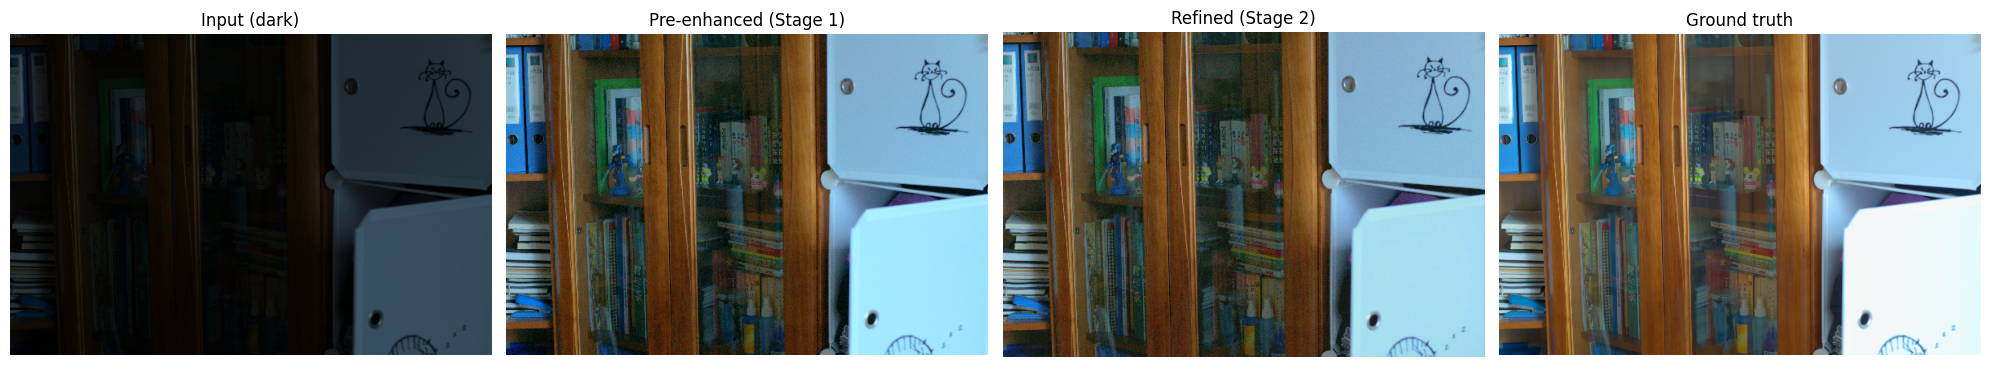

In [13]:
import matplotlib.pyplot as plt

G.eval()
low, high = test_ds[0]
low_t     = low.unsqueeze(0).to(device)

with torch.no_grad():
    pre_t     = AdaptiveToneMapping.pre_enhance(low_t)
    refined_t = G(pre_t)

to_np = lambda t: t.squeeze().permute(1, 2, 0).cpu().numpy().clip(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img, title in zip(
        axes,
        [to_np(low_t), to_np(pre_t), to_np(refined_t),
         to_np(high.unsqueeze(0).to(device))],
        ["Input (dark)", "Pre-enhanced (Stage 1)", "Refined (Stage 2)", "Ground truth"]):
    ax.imshow(img); ax.set_title(title, fontsize=12); ax.axis("off")
plt.tight_layout(); plt.show()
